<a href="https://colab.research.google.com/github/Amith1434/ML_Book_Journy/blob/main/Classification_(ML_Book).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Chapter3
##Classification model

In [1]:
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784',version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [2]:
X,y=mnist["data"],mnist["target"]

In [3]:
X.shape,y.shape

((70000, 784), (70000,))

784 is the pixel size, 70,000 is the number of images

In [4]:
X.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt

digit_1=X.iloc[0].values
digit_1.shape

(784,)

To view the image we have change it's resolution to 28 X 28

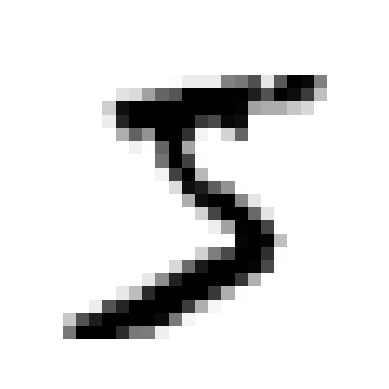

In [6]:
digit_1_reshape=digit_1.reshape(28,28)
plt.imshow(digit_1_reshape,cmap=mpl.cm.binary)
plt.axis("off")
plt.show()

In [7]:
y[0]

'5'

In [8]:
import numpy as np
y=y.astype(np.uint8)

In [9]:
y[0]

np.uint8(5)

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=.3)

training a model that is capable of classifing only one number (5 or not 5)


In [11]:
y_train_5=(y_train==5)
y_test_5=(y_test==5)

Picking the model

In [12]:
from sklearn.linear_model import SGDClassifier
sgd_clf=SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)

SGDClassifier(random_state=42)

In [13]:
sgd_clf.predict(X.iloc[[0]])

array([ True])

In [14]:
X_train.ndim

2

In [15]:
X.ndim

2

In [16]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,X_train,y_train_5,cv=3,scoring='accuracy')

array([0.96761357, 0.9631421 , 0.96106043])

In [17]:
from warnings import filterwarnings
filterwarnings("ignore")

In [18]:
from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
  def fit(self,X,y=None):
    pass
  def predict(self,X):
    return np.zeros((len(X),1),dtype=bool)
never_5_clf=Never5Classifier()
cross_val_score(never_5_clf,X_train,y_train_5,cv=3,scoring='accuracy')

array([0.91122811, 0.91024307, 0.90926345])

In [19]:
from sklearn.model_selection import cross_val_predict
y_train_pred=cross_val_predict(sgd_clf,X_train,y_train_5,cv=3)

In [20]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5,y_train_pred)

array([[43846,   756],
       [ 1011,  3387]])

In [21]:
from sklearn.metrics import precision_score,recall_score
precision_score(y_train_5,y_train_pred)

0.8175235336712527

In [22]:
recall_score(y_train_5,y_train_pred)

0.7701227830832197

In [23]:
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7931155602388479

sgd_clf.decision_function returns the score that the given image is 5 and then compares which the threshold (0) to classify the point

In [24]:
y_scores=sgd_clf.decision_function(X_train.iloc[[0]].values)
y_scores

array([-6948.88437797])

In [25]:
threshold=0
y_some_digit_pred=(y_scores>threshold)
y_some_digit_pred

array([False])

In [26]:
threshold=-7000
y_some_digit_pred=(y_scores>threshold)
y_some_digit_pred

array([ True])

<big>This proves that increasing the threshold decreases the recall</big>

In [27]:
y_scores=cross_val_predict(sgd_clf,X_train,y_train_5,cv=3,method='decision_function')
y_scores

array([-24865.08827364, -50292.78283928, -25793.36502201, ...,
       -10671.00799625, -12738.39920658, -27111.60240149])

In [28]:
y_train_5

,class
68681,False
19961,False
11040,False
27673,False
22876,False
...,...
37194,False
6265,False
54886,False
860,False


In [29]:
from sklearn.metrics import precision_recall_curve
precisions,recalls,thresholds=precision_recall_curve(y_train_5,y_scores)

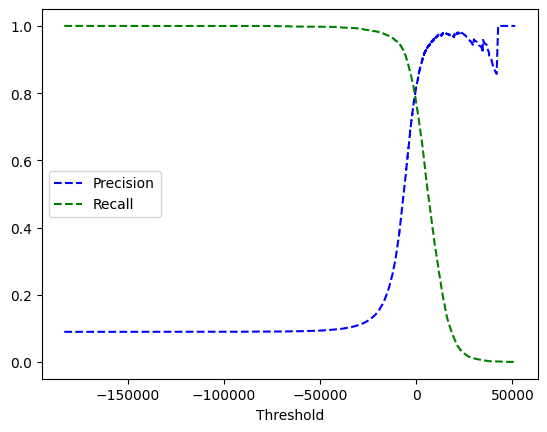

In [30]:
def plot_precision_recall_vs_threshold(precisions,recalls,thresholds):
  plt.plot(thresholds,precisions[:-1],"b--",label="Precision")
  plt.plot(thresholds,recalls[:-1],"g--",label="Recall")
  plt.xlabel("Threshold")
  plt.legend()
plot_precision_recall_vs_threshold(precisions,recalls,thresholds)

In [31]:
precisions.shape

(49001,)

In [32]:
X_train.shape

(49000, 784)

In [33]:
thresholds

array([-183129.34451759, -167162.14303701, -166231.10189384, ...,
         44946.21250166,   47962.29018551,   51450.2815451 ])

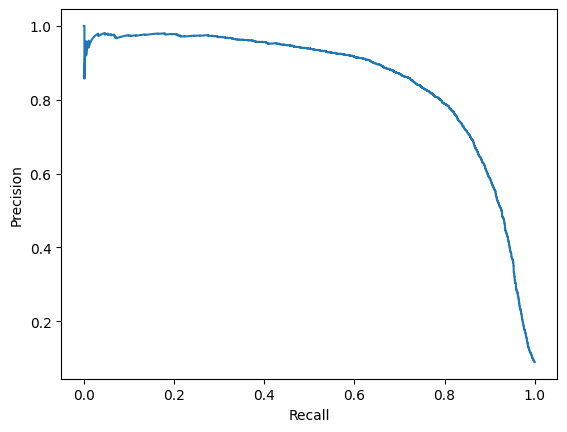

In [34]:
plt.plot(recalls,precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

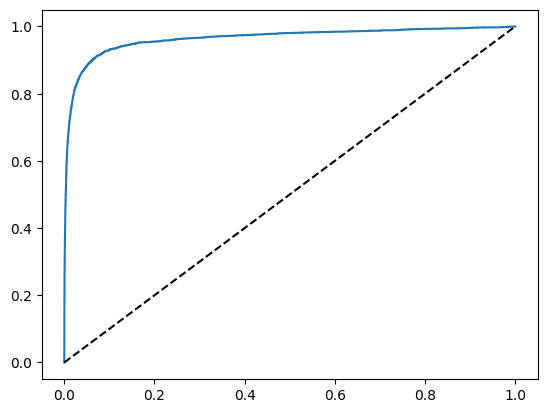

In [35]:
from sklearn.metrics import roc_curve
fpr,tpr,thresholds=roc_curve(y_train_5,y_scores)

def plot_roc_curve(fpr,tpr,label=None):
  plt.plot(fpr,tpr,label=label)
  plt.plot([0,1],[0,1],'k--')

plot_roc_curve(fpr,tpr)
plt.show()

In [36]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_scores)

np.float64(0.9644408219519376)

In [37]:
from sklearn.ensemble import RandomForestClassifier
forest_clf=RandomForestClassifier(random_state=42)
y_probas_forest=cross_val_predict(forest_clf,X_train,y_train_5,cv=3,method="predict_proba")

In [38]:
y_probas_forest

array([[0.98, 0.02],
       [1.  , 0.  ],
       [0.99, 0.01],
       ...,
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.99, 0.01]])

In [39]:
y_scores_forest=y_probas_forest[:,1]
fpr_forest,tpr_forest,thresholds_forest=roc_curve(y_train_5,y_scores_forest)

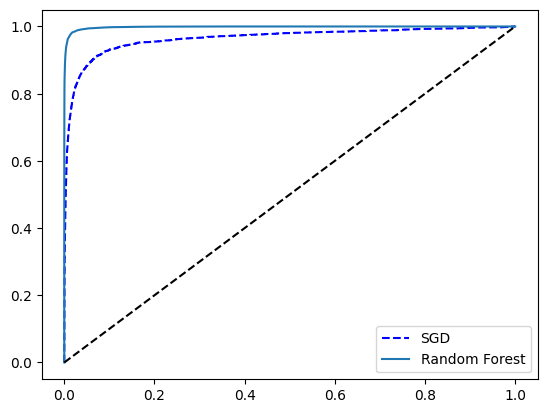

In [40]:
plt.plot(fpr,tpr,"b--",label="SGD")
plot_roc_curve(fpr_forest,tpr_forest,"Random Forest")
plt.legend(loc="lower right")
plt.show()

In [41]:
roc_auc_score(y_train_5,y_scores_forest)

np.float64(0.9983435350264486)

###Multiclass Classification


In [42]:
some_digit=X_train.iloc[0]
some_digit

,68681
pixel1,0
pixel2,0
pixel3,0
pixel4,0
pixel5,0
...,...
pixel780,0
pixel781,0
pixel782,0
pixel783,0


In [43]:
sgd_clf.fit(X_train,y_train)
sgd_clf.predict([some_digit])

array([0], dtype=uint8)

In [45]:
some_digit_scores=sgd_clf.decision_function([some_digit])
some_digit_scores

array([[  39413.98964611, -107781.40912039,  -12847.05138455,
         -16529.67797456,  -21528.64085662,   -7230.55495845,
         -33901.49048898,  -61536.18917388,  -22714.57540069,
         -34759.55841049]])

In [46]:
some_digit.ndim

1

In [47]:
np.argmax(some_digit_scores)

np.int64(0)

In [53]:
sgd_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [49]:
sgd_clf.classes_[5]

np.uint8(5)

In [51]:
from sklearn.multiclass import OneVsOneClassifier
ovo_clf=OneVsOneClassifier(SGDClassifier(random_state=42))
ovo_clf.fit(X_train, y_train)
ovo_clf.predict([some_digit])

array([0], dtype=uint8)

Training a RandomFroestClassifier is easier


In [54]:
forest_clf.fit(X_train,y_train)
forest_clf.predict([some_digit])

array([0], dtype=uint8)

In [55]:
forest_clf.predict_proba([some_digit])

array([[0.99, 0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.  , 0.  ]])

In [57]:
cross_val_score(sgd_clf,X_train,y_train,cv=3,scoring="accuracy")

array([0.84841435, 0.8884467 , 0.87099737])

In [58]:
y_train_pred=cross_val_predict(sgd_clf,X_train,y_train,cv=3)
conf_mx=confusion_matrix(y_train,y_train_pred)
conf_mx

array([[4637,    0,   28,   28,    8,   22,   55,    2,   58,    7],
       [   2, 5286,   45,   22,    6,   31,   13,   10,   77,   21],
       [  50,   69, 4076,  224,   61,   19,   75,   71,  185,   27],
       [  25,   20,  283, 4161,   18,  192,   18,   35,  125,   88],
       [  12,   17,   47,    9, 4439,    9,   41,   19,   37,  258],
       [  63,   15,   49,  211,   89, 3474,  102,   19,  227,  149],
       [  43,   21,   51,   12,   33,   85, 4478,    3,   56,    6],
       [  17,   19,   84,   41,   91,   10,    4, 4296,   33,  450],
       [  32,   98,  198,  371,   87,  198,   35,   18, 3586,  210],
       [  16,   20,   46,   65,  289,   74,    4,  111,   81, 4162]])

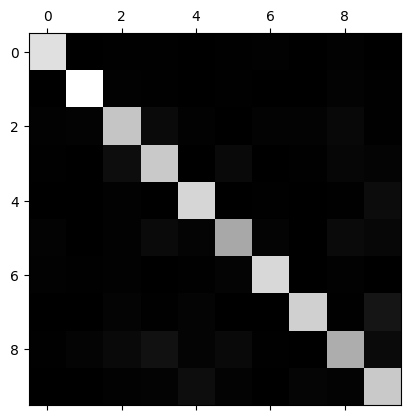

In [59]:
plt.matshow(conf_mx,cmap=plt.cm.gray)

 since most images are on the main diagonal,
which means that they were classified correctly. The 5s look slightly darker than the
other digits, which could mean that there are fewer images of 5s in the dataset or that
the classifier does not perform as well on 5s as on other digits. In fact, you can verify
that both are the case

In [60]:
row_sums=conf_mx.sum(axis=1,keepdims=True)
norm_conf_mx=conf_mx/row_sums

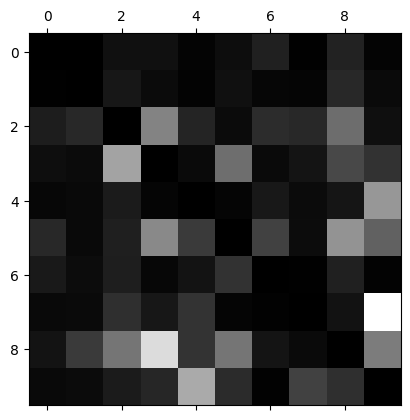

In [61]:
np.fill_diagonal(norm_conf_mx,0)
plt.matshow(norm_conf_mx,cmap=plt.cm.gray)
plt.show()

we can clearly see the kinds of errors the classifier makes

###MultiLabel Classification

In [62]:
from sklearn.neighbors import KNeighborsClassifier
y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier()

In [63]:
 knn_clf.predict([some_digit])


array([[False, False]])

it gets it right! The digit 0 is indeed not large (False) and odd (False)


In [64]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")


0.9748370741124373

###Multioutput Classification

In [66]:
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test